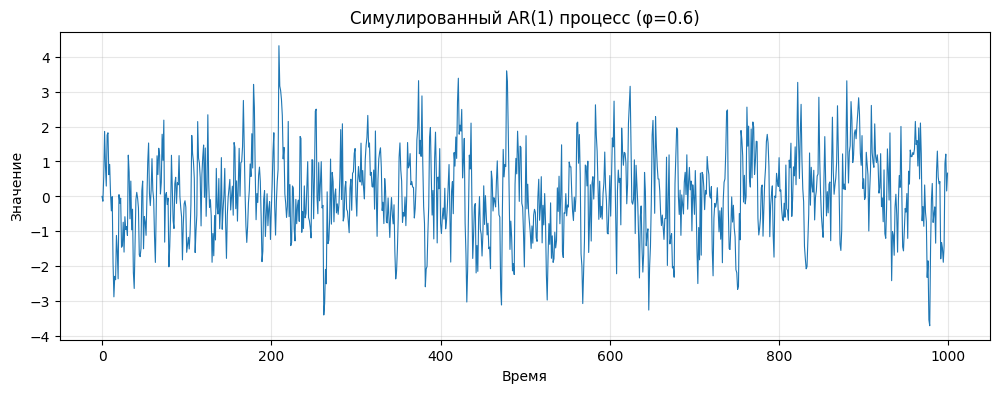

In [1]:
import numpy as np
import matplotlib.pyplot as plt
#import statsmodels.api as sm
#from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Параметры
phi = 0.6
sigma = 1.0
n = 1000  # длина ряда

# Генерация AR(1)
np.random.seed(42)
eps = np.random.normal(0, sigma, n)
X = np.zeros(n)
for t in range(1, n):
    X[t] = phi * X[t-1] + eps[t]

# Визуализация
plt.figure(figsize=(12, 4))
plt.plot(X, linewidth=0.8)
plt.title('Симулированный AR(1) процесс (φ=0.6)')
plt.xlabel('Время')
plt.ylabel('Значение')
plt.grid(alpha=0.3)
plt.show()

In [4]:
mu_hat = np.mean(X)
mu_hat

np.float64(0.046089629281265886)

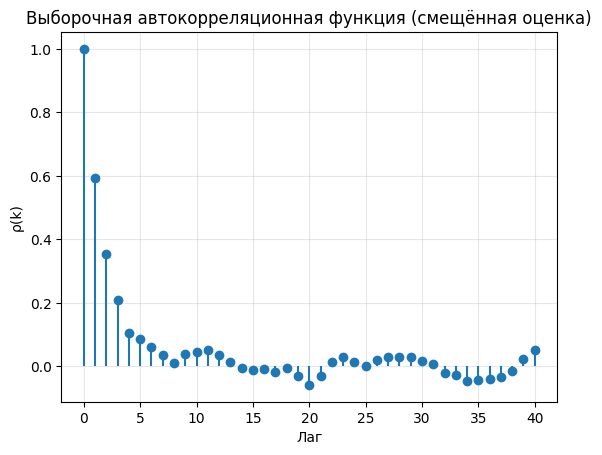

In [6]:
# Вычисление автоковариаций для лагов от 0 до max_lag
max_lag = 40
acvf = np.zeros(max_lag + 1)  # acvf[0] = γ(0)
for k in range(max_lag + 1):
    # Смещённая оценка (деление на n)
    acvf[k] = np.sum((X[:n-k] - mu_hat) * (X[k:] - mu_hat)) / (n-k)

# Автокорреляции
acf = acvf / acvf[0]   # ρ(0) = 1

# Визуализация
lags = np.arange(max_lag + 1)
plt.stem(lags, acf, basefmt=" ")
plt.title('Выборочная автокорреляционная функция (смещённая оценка)')
plt.xlabel('Лаг')
plt.ylabel('ρ(k)')
plt.grid(alpha=0.3)
plt.show()